<a href="https://colab.research.google.com/github/danielsmith-cloud/DSRP_inequality/blob/main/DSRP_pip_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Research Question:
Around COVID, how do the poverty and inequality rates change in the top, bottom, and middle income countries? How have they overcome their struggles during and after it?

This may help countries recover faster after future events that cause higher poverty.

# **Installation and Importing**

In [1]:
!pip install matplotlib
import matplotlib.pyplot as plt

!pip install pandas
import pandas as pd

!pip install numpy
import numpy as np

!pip install seaborn
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
url = "https://raw.githubusercontent.com/owid/poverty-data/refs/heads/main/datasets/pip_dataset.csv"
url2 = "https://raw.githubusercontent.com/owid/poverty-data/refs/heads/main/datasets/pip_codebook.csv"
pip_df = pd.read_csv(url)
pip_codebook = pd.read_csv(url2)

# **View Data**

In [3]:
pip_df

,country,year,reporting_level,welfare_type,ppp_version,survey_year,survey_comparability,headcount_ratio_international_povline,headcount_ratio_lower_mid_income_povline,headcount_ratio_upper_mid_income_povline,...,decile8_thr,decile9_thr,gini,mld,polarization,palma_ratio,s80_s20_ratio,p90_p10_ratio,p90_p50_ratio,p50_p10_ratio
0,Albania,1996,national,consumption,2011,1996.0,0.0,0.920669,11.174149,44.618417,...,8.85,10.92,0.270103,0.119104,0.241293,0.928335,3.945872,3.568627,1.889273,1.888889
1,Albania,2002,national,consumption,2011,2002.0,1.0,1.570843,14.132118,49.669635,...,8.83,11.58,0.317390,0.164812,0.268982,1.215056,4.831625,3.979381,2.090253,1.903780
2,Albania,2005,national,consumption,2011,2005.0,1.0,0.860527,8.715685,38.545254,...,10.02,12.78,0.305957,0.154413,0.254529,1.142718,4.662236,3.872727,1.978328,1.957576
3,Albania,2008,national,consumption,2011,2008.0,1.0,0.313650,5.250542,31.110345,...,10.74,13.62,0.299847,0.148893,0.247311,1.114657,4.395911,3.574803,1.956897,1.826772
4,Albania,2012,national,consumption,2011,2012.0,1.0,0.849754,6.182414,34.528906,...,10.52,13.26,0.289605,0.138417,0.249988,1.041193,4.272573,3.632877,1.941435,1.871233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4872,Zambia,2010,national,consumption,2017,2010.0,4.0,68.456606,82.885088,93.044964,...,3.27,5.34,0.556215,0.539135,0.536149,4.278696,16.024650,10.470588,3.955556,2.647059
4873,Zambia,2015,national,consumption,2017,2015.0,4.0,61.352160,77.548045,90.747141,...,4.02,6.43,0.571361,0.604667,0.613181,4.995829,21.243915,13.978261,4.095541,3.413043
4874,Zimbabwe,2011,national,consumption,2017,2011.0,0.0,21.580063,47.857143,77.945113,...,7.25,10.54,0.431536,0.311153,0.388356,2.207938,8.526847,6.713376,2.773684,2.420382
4875,Zimbabwe,2017,national,consumption,2017,2017.0,0.0,34.206046,61.583570,84.109019,...,5.96,8.81,0.443371,0.322848,0.416694,2.307359,8.569542,6.574627,3.069686,2.141791


In [4]:
pip_codebook.iloc[60:80]

,column,description
60,income_gap_ratio_50_median,The average shortfall from a poverty line of t...
61,income_gap_ratio_60_median,The average shortfall from a poverty line of t...
62,poverty_gap_index_international_povline,The poverty gap index calculated at the Intern...
63,poverty_gap_index_lower_mid_income_povline,The poverty gap index calculated at the lower-...
64,poverty_gap_index_upper_mid_income_povline,The poverty gap index calculated atthe upper-m...
65,poverty_gap_index_100,The poverty gap index calculated at a poverty ...
66,poverty_gap_index_1000,The poverty gap index calculated at a poverty ...
67,poverty_gap_index_2000,The poverty gap index calculated at a poverty ...
68,poverty_gap_index_3000,The poverty gap index calculated at a poverty ...
69,poverty_gap_index_4000,The poverty gap index calculated at a poverty ...


In [5]:
pip_df.describe()

,year,ppp_version,survey_year,survey_comparability,headcount_ratio_international_povline,headcount_ratio_lower_mid_income_povline,headcount_ratio_upper_mid_income_povline,headcount_ratio_100,headcount_ratio_1000,headcount_ratio_2000,...,decile8_thr,decile9_thr,gini,mld,polarization,palma_ratio,s80_s20_ratio,p90_p10_ratio,p90_p50_ratio,p50_p10_ratio
count,4877.000000,4877.000000,4411.000000,4411.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,...,4877.000000,4877.000000,4401.000000,4401.000000,4401.000000,4395.000000,4395.000000,4877.000000,4877.000000,4877.000000
mean,2005.759893,2013.999385,2005.939896,1.639084,11.081565,21.672687,36.538818,3.164721,50.351520,69.105964,...,26.273736,35.110607,0.375645,0.264371,0.327385,1.886528,8.219764,7.424451,2.532256,2.660335
std,9.438782,3.000308,9.497211,1.402898,18.190433,27.104145,33.674140,7.568626,36.002943,34.132391,...,24.171141,30.671393,0.088840,0.140325,0.101136,1.138502,6.018946,42.891943,0.954387,11.785204
min,1967.000000,2011.000000,1967.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.920154,...,1.010000,1.460000,0.177920,0.053563,0.146643,0.596408,2.430173,2.191176,1.475248,1.485294
25%,2000.000000,2011.000000,2000.000000,1.000000,0.278387,0.807877,3.032081,0.044772,10.328433,44.575897,...,8.680000,11.960000,0.308719,0.163090,0.252448,1.154071,4.720943,3.937500,2.017751,1.942113
50%,2007.000000,2011.000000,2007.000000,1.000000,2.041412,9.186717,28.582685,0.371755,55.337658,84.916259,...,16.980000,24.560000,0.355622,0.220968,0.300364,1.465800,6.171947,5.149826,2.290076,2.207904
75%,2013.000000,2017.000000,2014.000000,2.000000,13.390963,34.166712,64.864719,2.158480,85.133887,97.179433,...,35.550000,48.350000,0.427676,0.320859,0.380201,2.152142,9.043292,7.458333,2.780911,2.740385
max,2021.000000,2017.000000,2021.000000,6.000000,96.871427,99.999000,99.999000,79.532619,99.999000,100.000000,...,120.100000,164.700000,0.657556,0.937047,0.815704,8.343586,72.681737,2892.000000,11.491525,809.000000


In [6]:
print(pip_df.columns.tolist())
print("")
pip_df.info()

['country', 'year', 'reporting_level', 'welfare_type', 'ppp_version', 'survey_year', 'survey_comparability', 'headcount_ratio_international_povline', 'headcount_ratio_lower_mid_income_povline', 'headcount_ratio_upper_mid_income_povline', 'headcount_ratio_100', 'headcount_ratio_1000', 'headcount_ratio_2000', 'headcount_ratio_3000', 'headcount_ratio_4000', 'headcount_ratio_40_median', 'headcount_ratio_50_median', 'headcount_ratio_60_median', 'headcount_international_povline', 'headcount_lower_mid_income_povline', 'headcount_upper_mid_income_povline', 'headcount_100', 'headcount_1000', 'headcount_2000', 'headcount_3000', 'headcount_4000', 'headcount_40_median', 'headcount_50_median', 'headcount_60_median', 'avg_shortfall_international_povline', 'avg_shortfall_lower_mid_income_povline', 'avg_shortfall_upper_mid_income_povline', 'avg_shortfall_100', 'avg_shortfall_1000', 'avg_shortfall_2000', 'avg_shortfall_3000', 'avg_shortfall_4000', 'avg_shortfall_40_median', 'avg_shortfall_50_median', '

For my Research Question, I will need the variables: Country, Year, Headcount 1000, Headcount Ratio 60 Median, Mean, Median, Gini, Mld, Palma Ratio, and p50 to p10 ratio. I will pick 4 countries from the top income, 4 from the middle income, and 4 from the lower income(bar graph). I will then compare their rates by time(line graph) and then research what the highest changed countries have done to contribute to the effort.

--Lookup how much the countries were affected.--

# **Cleaning Data**

In [7]:
pip_df.isna().sum()

,0
country,0
year,0
reporting_level,466
welfare_type,466
ppp_version,0
...,...
palma_ratio,482
s80_s20_ratio,482
p90_p10_ratio,0
p90_p50_ratio,0


In [8]:
pip_df.drop_duplicates()
pip_df.dropna()
pip_df.columns = pip_df.columns.str.replace('_', ' ').str.title()
rep_df = pip_df[pip_df['Reporting Level'] == "national"]
covid_df = rep_df[(rep_df['Survey Year'] >= 2017) & (rep_df['Survey Year'] <= 2022)]
final_df = covid_df[['Country', 'Year', 'Headcount 1000', 'Headcount Ratio 60 Median', 'Mean', 'Median', 'Gini', 'Mld', 'Palma Ratio', 'P50 P10 Ratio']]
final_df.isna().sum().sum()

np.int64(4)

In [9]:
final_df

,Country,Year,Headcount 1000,Headcount Ratio 60 Median,Mean,Median,Gini,Mld,Palma Ratio,P50 P10 Ratio
9,Albania,2017,1737879.0,19.173047,10.279880,8.438173,0.330557,0.179908,1.259837,2.078818
10,Albania,2017,2003124.0,25.204690,8.623164,7.210040,0.370951,0.254175,1.567077,2.907258
11,Albania,2018,1511924.0,18.660276,11.029705,9.641079,0.301483,0.152404,1.083829,2.128035
12,Albania,2018,1943429.0,24.416475,9.025892,7.619805,0.359888,0.233051,1.482572,2.683099
13,Albania,2019,1251393.0,16.576506,12.905641,10.831646,0.307717,0.154626,1.132010,1.967332
...,...,...,...,...,...,...,...,...,...,...
4801,Uruguay,2020,598797.0,25.152774,26.653744,20.375712,0.401521,0.277025,1.871049,2.619537
4807,Vanuatu,2019,274186.0,20.695800,5.427668,4.670875,0.323176,0.176084,1.242286,2.172093
4831,Vietnam,2018,41829267.0,20.392684,13.460410,10.921968,0.357155,0.219244,1.479456,2.313559
4875,Zimbabwe,2017,13163332.0,21.555514,4.409205,2.874558,0.443371,0.322848,2.307359,2.141791


# **Separating and Viewing Data**
top - middle - bottom (income)

In [10]:
described = final_df.describe()
described

,Year,Headcount 1000,Headcount Ratio 60 Median,Mean,Median,Gini,Mld,Palma Ratio,P50 P10 Ratio
count,498.000000,4.980000e+02,498.000000,498.000000,498.000000,498.000000,498.000000,494.000000,498.000000
mean,2018.092369,3.835807e+07,19.178038,25.011530,20.514031,0.357317,0.233551,1.601476,2.277095
std,0.947039,1.592446e+08,5.275091,19.691671,16.999727,0.071068,0.098449,0.676726,0.501823
min,2017.000000,7.630000e+02,9.011694,1.708733,1.266588,0.232323,0.097363,0.745285,1.631399
25%,2017.000000,3.114745e+05,15.243344,10.786768,8.423640,0.301483,0.155861,1.090819,1.915544
50%,2018.000000,2.237358e+06,19.319040,18.587469,13.617742,0.352226,0.220018,1.429495,2.130813
75%,2019.000000,1.221833e+07,22.995974,33.369526,27.838159,0.403790,0.277477,1.895029,2.520053
max,2021.000000,1.281345e+09,31.132777,85.874727,69.483560,0.541740,0.554069,4.135306,3.875676


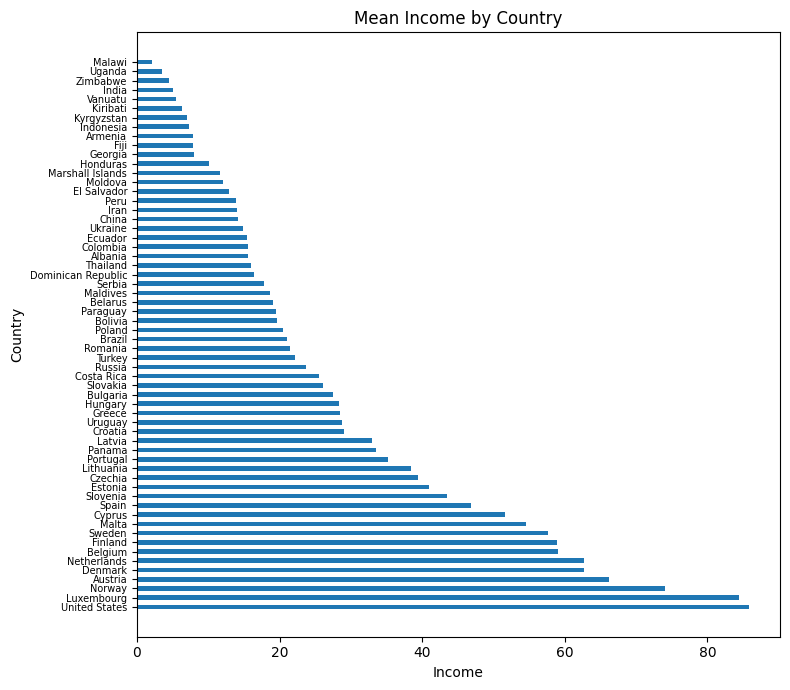

In [11]:
top_df = final_df[final_df['Year'] == 2019]
top_df = top_df.drop_duplicates(subset=['Country'], keep='last')
top_df = top_df.sort_values(by='Mean', ascending=False)
plt.figure(figsize=(8, 7))
plt.title("Mean Income by Country")
plt.ylabel("Country")
plt.xlabel("Income")
plt.barh(top_df['Country'], top_df['Mean'], height=0.5)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

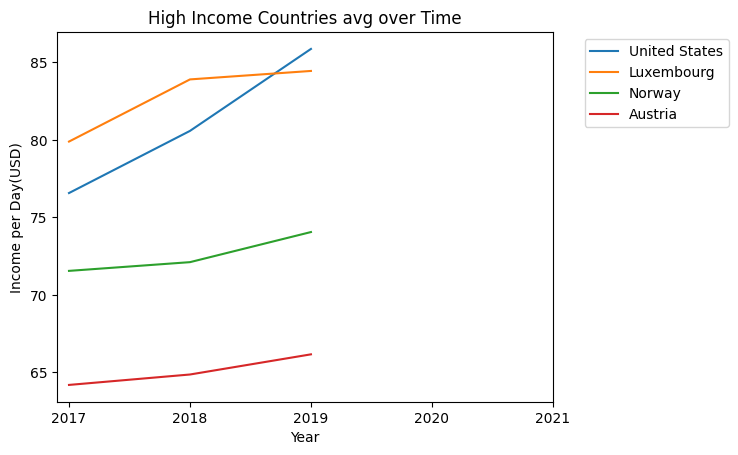

In [14]:
united = final_df[final_df['Country'] == 'United States']
united = united.sort_values(by='Year')
united = united.drop_duplicates(subset=['Year'], keep='last')
luxem = final_df[final_df['Country'] == 'Luxembourg']
luxem = luxem.sort_values(by='Year')
luxem = luxem.drop_duplicates(subset=['Year'], keep='last')
norway = final_df[final_df['Country'] == 'Norway']
norway = norway.sort_values(by='Year')
norway = norway.drop_duplicates(subset=['Year'], keep='last')
austria = final_df[final_df['Country'] == 'Austria']
austria = austria.sort_values(by='Year')
austria = austria.drop_duplicates(subset=['Year'], keep='last')

plt.plot(united['Year'], united['Mean'], label='United States')
plt.plot(luxem['Year'], luxem['Mean'], label='Luxembourg')
plt.plot(norway['Year'], norway['Mean'], label='Norway')
plt.plot(austria['Year'], austria['Mean'], label='Austria')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("High Income Countries avg over Time")
plt.xlabel("Year")
plt.ylabel("Income per Day(USD)")
plt.ticklabel_format(useOffset=False, style='plain')
plt.xticks(range(2017, 2022, 1))
plt.show()

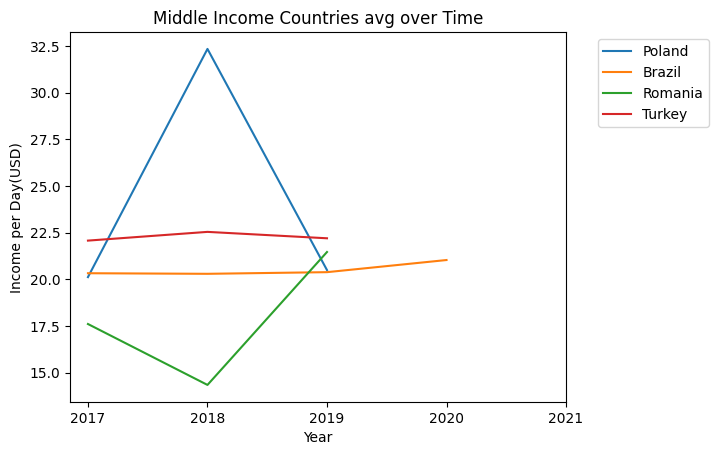

In [15]:
poland = final_df[final_df['Country'] == 'Poland']
poland = poland.sort_values(by='Year')
poland = poland.drop_duplicates(subset=['Year'], keep='last')
brazil = final_df[final_df['Country'] == 'Brazil']
brazil = brazil.sort_values(by='Year')
brazil = brazil.drop_duplicates(subset=['Year'], keep='last')
romania = final_df[final_df['Country'] == 'Romania']
romania = romania.sort_values(by='Year')
romania = romania.drop_duplicates(subset=['Year'], keep='last')
turkey = final_df[final_df['Country'] == 'Turkey']
turkey = turkey.sort_values(by='Year')
turkey = turkey.drop_duplicates(subset=['Year'], keep='last')

plt.plot(poland['Year'], poland['Mean'], label='Poland')
plt.plot(brazil['Year'], brazil['Mean'], label='Brazil')
plt.plot(romania['Year'], romania['Mean'], label='Romania')
plt.plot(turkey['Year'], turkey['Mean'], label='Turkey')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Middle Income Countries avg over Time")
plt.xlabel("Year")
plt.ylabel("Income per Day(USD)")
plt.ticklabel_format(useOffset=False, style='plain')
plt.xticks(range(2017, 2022, 1))
plt.show()

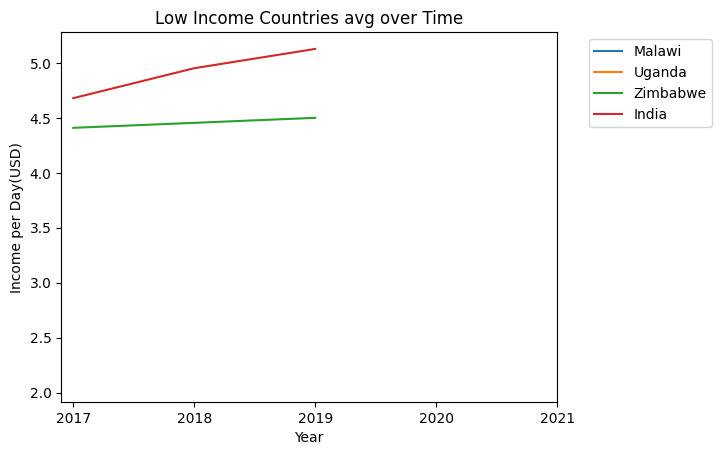

In [16]:
malawi = final_df[final_df['Country'] == 'Malawi']
malawi = malawi.sort_values(by='Year')
malawi = malawi.drop_duplicates(subset=['Year'], keep='last')
uganda = final_df[final_df['Country'] == 'Uganda']
uganda = uganda.sort_values(by='Year')
uganda = uganda.drop_duplicates(subset=['Year'], keep='last')
zimbabwe = final_df[final_df['Country'] == 'Zimbabwe']
zimbabwe = zimbabwe.sort_values(by='Year')
zimbabwe = zimbabwe.drop_duplicates(subset=['Year'], keep='last')
india = final_df[final_df['Country'] == 'India']
india = india.sort_values(by='Year')
india = india.drop_duplicates(subset=['Year'], keep='last')

plt.plot(malawi['Year'], malawi['Mean'], label='Malawi')
plt.plot(uganda['Year'], uganda['Mean'], label='Uganda')
plt.plot(zimbabwe['Year'], zimbabwe['Mean'], label='Zimbabwe')
plt.plot(india['Year'], india['Mean'], label='India')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Low Income Countries avg over Time")
plt.xlabel("Year")
plt.ylabel("Income per Day(USD)")
plt.ticklabel_format(useOffset=False, style='plain')
plt.xticks(range(2017, 2022, 1))
plt.show()